# Attention, Boredom, and Doomscrolling  
## Collaborative working notebook

This is the group version of the notebook.

It keeps the project motivation, but it is written so multiple people can contribute without needing to rebuild the whole structure.

### Project motivation
This project started from a simple question:
what happens to our brain and attention when we keep getting pulled into repetitive content, like doomscrolling?

We are not claiming that this notebook directly detects doomscrolling.
Instead, we use public brain-signal datasets to study lower-engagement and higher-engagement proxy conditions.

### Main question
How can public brain-signal data help us study patterns related to lower engagement, boredom-like states, and attention drift?

### What this notebook is for
- a shared coding space
- a readable analysis document
- a place to show visuals, outputs, and notes
- a place for each teammate to push one part forward

## How this collaboration version works

This notebook is designed for **Google Colab without Google Drive**.

That means:
- you can upload files using the folder icon on the left
- everything will live inside the current Colab runtime
- the notebook can still be shared with teammates
- but uploaded runtime files are temporary

### Important warning
The notebook itself can be shared.
The uploaded data files in the runtime are **not** shared with the notebook and do **not** stay forever.

So this version is good for:
- fast setup
- team experimentation
- class demos

It is not the best long-term storage method.

## What each person can do here

### Research / writing
- improve the intro
- refine the question
- add short interpretation under each plot

### Data / loading
- check file paths
- verify file formats
- test more subjects

### Signal / preprocessing
- improve filtering
- improve window selection
- test cleaner segment definitions

### ML / evaluation
- test Logistic Regression
- compare with SVM later
- improve labels and evaluation

### Visualization
- improve plot labels and titles
- add better comparison plots
- improve the scalp heatmap or signal visual

## File upload workflow in Colab

### Folder structure inside Colab
When you upload files into Colab, this notebook will build folders inside `/content`.

Expected layout:

```text
/content/attention_boredom_project/
├── data/
│   ├── alpha_waves/
│   ├── mental_arithmetic/
│   └── openneuro_optional/
└── processed/
```

### What to upload
1. Alpha Waves `.mat` files into:
`/content/attention_boredom_project/data/alpha_waves/`

2. Mental Arithmetic `.edf` files into:
`/content/attention_boredom_project/data/mental_arithmetic/`

3. Optional OpenNeuro files later into:
`/content/attention_boredom_project/data/openneuro_optional/`



In [ ]:
# 1. Install packages
!pip -q install mne pyedflib scipy pandas matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 51.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.


In [ ]:
# 2. Create local project folders in Colab
from pathlib import Path

ROOT = Path('/content/attention_boredom_project')
RAW_ALPHA = ROOT / 'data' / 'alpha_waves'
RAW_MENTAL = ROOT / 'data' / 'mental_arithmetic'
RAW_OPENNEURO = ROOT / 'data' / 'openneuro_optional'
PROCESSED = ROOT / 'processed'

for folder in [ROOT, RAW_ALPHA, RAW_MENTAL, RAW_OPENNEURO, PROCESSED]:
    folder.mkdir(parents=True, exist_ok=True)

print('Root:', ROOT)
print('Alpha folder:', RAW_ALPHA)
print('Mental folder:', RAW_MENTAL)
print('OpenNeuro optional folder:', RAW_OPENNEURO)

Root: /content/attention_boredom_project
Alpha folder: /content/attention_boredom_project/data/alpha_waves
Mental folder: /content/attention_boredom_project/data/mental_arithmetic
OpenNeuro optional folder: /content/attention_boredom_project/data/openneuro_optional


## Before running the analysis

Use the **folder icon on the left side of Colab** and upload files into the folders above.

If you prefer, you can also upload a zip file and unzip it with code.

After uploading, rerun the next cell to check the file counts.

In [ ]:
# 3. Check uploaded files
alpha_files = list(RAW_ALPHA.glob('*.mat'))
mental_files = list(RAW_MENTAL.rglob('*.edf'))

print('Alpha Waves .mat files found:', len(alpha_files))
print('Mental Arithmetic .edf files found:', len(mental_files))

if len(alpha_files) == 0:
    print('Upload Alpha Waves .mat files first.')

if len(mental_files) == 0:
    print('Upload Mental Arithmetic .edf files first.')

Alpha Waves .mat files found: 20
Mental Arithmetic .edf files found: 72


In [ ]:
# 4. Imports
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat
from scipy.signal import welch, spectrogram

import mne
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')
mne.set_log_level('ERROR')

## Analysis idea

This notebook uses simple interpretable features:

- theta power, 4 to 7 Hz
- alpha power, 8 to 12 Hz
- beta power, 13 to 30 Hz
- alpha/beta ratio
- beta/alpha ratio

Main first comparison:
- lower engagement proxy: eyes closed
- higher engagement proxy: mental arithmetic task

In [ ]:
# 5. Helper functions
ALPHA_CHANNELS = [
    'Fp1', 'Fp2', 'FC5', 'FC6', 'Fz', 'T7', 'Cz', 'T8',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'O1', 'Oz', 'O2'
]

def find_main_numeric_matrix(mat_dict):
    candidates = []
    for key, value in mat_dict.items():
        if key.startswith('__'):
            continue
        if isinstance(value, np.ndarray) and np.issubdtype(value.dtype, np.number) and value.ndim == 2:
            candidates.append((key, value))
    if not candidates:
        raise ValueError('No numeric 2D matrix found in .mat file')
    key, arr = max(candidates, key=lambda kv: kv[1].size)
    return key, arr

def bandpower(data, sfreq, band, total_band=(1, 40)):
    data = np.asarray(data)
    if data.ndim == 1:
        data = data[:, None]
    if data.shape[0] < data.shape[1]:
        data = data.T

    nperseg = min(int(2 * sfreq), data.shape[0])
    if nperseg < 8:
        raise ValueError('Segment too short for Welch PSD')

    freqs, psd = welch(data, fs=sfreq, nperseg=nperseg, axis=0)

    band_mask = (freqs >= band[0]) & (freqs <= band[1])
    total_mask = (freqs >= total_band[0]) & (freqs <= total_band[1])

    bp = np.trapz(psd[band_mask], freqs[band_mask], axis=0)
    total = np.trapz(psd[total_mask], freqs[total_mask], axis=0)

    return float(np.mean(bp)), float(np.mean(bp / (total + 1e-12)))

def compute_features_from_array(data, sfreq):
    theta_abs, theta_rel = bandpower(data, sfreq, (4, 7))
    alpha_abs, alpha_rel = bandpower(data, sfreq, (8, 12))
    beta_abs, beta_rel = bandpower(data, sfreq, (13, 30))

    return {
        'theta_power': theta_abs,
        'alpha_power': alpha_abs,
        'beta_power': beta_abs,
        'theta_rel_power': theta_rel,
        'alpha_rel_power': alpha_rel,
        'beta_rel_power': beta_rel,
        'alpha_beta_ratio': alpha_abs / (beta_abs + 1e-12),
        'beta_alpha_ratio': beta_abs / (alpha_abs + 1e-12),
        'theta_beta_ratio': theta_abs / (beta_abs + 1e-12),
    }

## Load lower-engagement proxy data

The Alpha Waves dataset gives us:
- eyes closed
- eyes open

Eyes closed is our main low-engagement proxy in version 1.

In [ ]:
# 6. Load Alpha Waves dataset and extract segments

def extract_alpha_wave_segments(mat_path, block_seconds=10):
    mat = loadmat(mat_path)
    matrix_name, arr = find_main_numeric_matrix(mat)

    if arr.shape[1] < 19:
        raise ValueError(f'{mat_path.name} does not look like the expected Alpha Waves format')

    timestamps = arr[:, 0].astype(float)
    eeg = arr[:, 1:17].astype(float)
    trig_closed = arr[:, 17].astype(float)
    trig_open = arr[:, 18].astype(float)

    dt = np.median(np.diff(timestamps))
    sfreq = round(1.0 / dt) if dt > 0 else 512
    win = int(block_seconds * sfreq)

    rows = []
    raw_segments = []

    for state_name, trig in [('eyes_closed', trig_closed), ('eyes_open', trig_open)]:
        starts = np.where(trig > 0)[0]
        for block_idx, start in enumerate(starts):
            segment = eeg[start:start + win]
            if len(segment) < win:
                continue

            feats = compute_features_from_array(segment, sfreq)
            feats.update({
                'dataset': 'alpha_waves',
                'subject': mat_path.stem,
                'condition': state_name,
                'segment_id': f'{mat_path.stem}_{state_name}_{block_idx}',
                'sfreq': sfreq,
                'source_file': str(mat_path),
                'mat_variable': matrix_name,
            })
            rows.append(feats)

            raw_segments.append({
                'subject': mat_path.stem,
                'condition': state_name,
                'segment': segment,
                'sfreq': sfreq
            })

    return pd.DataFrame(rows), raw_segments

alpha_files = sorted(RAW_ALPHA.glob('*.mat'))

if len(alpha_files) == 0:
    alpha_features = pd.DataFrame()
    alpha_segments = []
    print('No Alpha Waves files found yet.')
else:
    alpha_tables = []
    alpha_segments = []
    for path in alpha_files:
        df, segs = extract_alpha_wave_segments(path)
        alpha_tables.append(df)
        alpha_segments.extend(segs)

    alpha_features = pd.concat(alpha_tables, ignore_index=True)
    print('Alpha Waves features shape:', alpha_features.shape)
    display(alpha_features.head())

Alpha Waves features shape: (200, 16)


,theta_power,alpha_power,beta_power,theta_rel_power,alpha_rel_power,beta_rel_power,alpha_beta_ratio,beta_alpha_ratio,theta_beta_ratio,dataset,subject,condition,segment_id,sfreq,source_file,mat_variable
0,5.210655,93.162882,12.470050,0.037524,0.477149,0.081736,7.470931,0.133852,0.417854,alpha_waves,subject_00,eyes_closed,subject_00_eyes_closed_0,512,/content/attention_boredom_project/data/alpha_...,SIGNAL
1,5.481269,78.101076,11.413024,0.060056,0.523869,0.108489,6.843154,0.146131,0.480264,alpha_waves,subject_00,eyes_closed,subject_00_eyes_closed_1,512,/content/attention_boredom_project/data/alpha_...,SIGNAL
2,5.817282,73.197516,11.969411,0.048751,0.480743,0.099228,6.115382,0.163522,0.486012,alpha_waves,subject_00,eyes_closed,subject_00_eyes_closed_2,512,/content/attention_boredom_project/data/alpha_...,SIGNAL
3,7.008290,85.622124,11.847252,0.054103,0.536847,0.092613,7.227172,0.138367,0.591554,alpha_waves,subject_00,eyes_closed,subject_00_eyes_closed_3,512,/content/attention_boredom_project/data/alpha_...,SIGNAL
4,8.289877,96.267975,11.174994,0.051538,0.478829,0.069822,8.614588,0.116082,0.741824,alpha_waves,subject_00,eyes_closed,subject_00_eyes_closed_4,512,/content/attention_boredom_project/data/alpha_...,SIGNAL


## Load higher-engagement proxy data

The Mental Arithmetic dataset gives us:
- background
- mental arithmetic task

The mental arithmetic condition is our main high-engagement proxy in version 1.

In [ ]:
# 7. Load Mental Arithmetic dataset

def extract_mental_arithmetic_features(edf_path):
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
    raw.pick('eeg')
    data = raw.get_data().T
    sfreq = float(raw.info['sfreq'])

    feats = compute_features_from_array(data, sfreq)
    condition = 'mental_math' if edf_path.stem.endswith('_2') else 'baseline'
    subject = edf_path.stem.rsplit('_', 1)[0]

    feats.update({
        'dataset': 'mental_arithmetic',
        'subject': subject,
        'condition': condition,
        'segment_id': edf_path.stem,
        'sfreq': sfreq,
        'source_file': str(edf_path),
    })

    return feats, {'subject': subject, 'condition': condition, 'segment': data, 'sfreq': sfreq}

mental_files = sorted(RAW_MENTAL.rglob('*.edf'))

if len(mental_files) == 0:
    mental_features = pd.DataFrame()
    mental_segments = []
    print('No Mental Arithmetic files found yet.')
else:
    mental_rows = []
    mental_segments = []
    for path in mental_files:
        feats, seg = extract_mental_arithmetic_features(path)
        mental_rows.append(feats)
        mental_segments.append(seg)

    mental_features = pd.DataFrame(mental_rows)
    print('Mental Arithmetic features shape:', mental_features.shape)
    display(mental_features.head())

Mental Arithmetic features shape: (72, 15)


,theta_power,alpha_power,beta_power,theta_rel_power,alpha_rel_power,beta_rel_power,alpha_beta_ratio,beta_alpha_ratio,theta_beta_ratio,dataset,subject,condition,segment_id,sfreq,source_file
0,1.343204e-10,1.870860e-10,1.322156e-10,0.092525,0.371778,0.148238,1.404385,0.702953,1.008293,mental_arithmetic,Subject00,baseline,Subject00_1,500.0,/content/attention_boredom_project/data/mental...
1,1.263706e-10,2.025419e-10,1.479777e-10,0.096970,0.314671,0.159675,1.359545,0.727013,0.848252,mental_arithmetic,Subject00,mental_math,Subject00_2,500.0,/content/attention_boredom_project/data/mental...
2,6.284999e-11,5.829117e-11,5.439774e-11,0.115946,0.185285,0.198548,1.052230,0.917468,1.134523,mental_arithmetic,Subject01,baseline,Subject01_1,500.0,/content/attention_boredom_project/data/mental...
3,5.622931e-11,4.306029e-11,4.954199e-11,0.142672,0.114607,0.133226,0.851971,1.124414,1.112527,mental_arithmetic,Subject01,mental_math,Subject01_2,500.0,/content/attention_boredom_project/data/mental...
4,1.030294e-11,2.953288e-11,2.261835e-11,0.082526,0.229581,0.189395,1.250421,0.740786,0.436226,mental_arithmetic,Subject02,baseline,Subject02_1,500.0,/content/attention_boredom_project/data/mental...


## Combine the feature tables

In [ ]:
# 8. Combine tables
frames = []
if len(alpha_features) > 0:
    frames.append(alpha_features)
if len(mental_features) > 0:
    frames.append(mental_features)

if len(frames) == 0:
    features = pd.DataFrame()
    print('No data loaded yet.')
else:
    features = pd.concat(frames, ignore_index=True)
    print('Combined feature shape:', features.shape)
    print(features['condition'].value_counts(dropna=False))
    display(features.head())

Combined feature shape: (272, 16)
condition
eyes_closed    100
eyes_open      100
baseline        36
mental_math     36
Name: count, dtype: int64


,theta_power,alpha_power,beta_power,theta_rel_power,alpha_rel_power,beta_rel_power,alpha_beta_ratio,beta_alpha_ratio,theta_beta_ratio,dataset,subject,condition,segment_id,sfreq,source_file,mat_variable
0,5.210655,93.162882,12.470050,0.037524,0.477149,0.081736,7.470931,0.133852,0.417854,alpha_waves,subject_00,eyes_closed,subject_00_eyes_closed_0,512.0,/content/attention_boredom_project/data/alpha_...,SIGNAL
1,5.481269,78.101076,11.413024,0.060056,0.523869,0.108489,6.843154,0.146131,0.480264,alpha_waves,subject_00,eyes_closed,subject_00_eyes_closed_1,512.0,/content/attention_boredom_project/data/alpha_...,SIGNAL
2,5.817282,73.197516,11.969411,0.048751,0.480743,0.099228,6.115382,0.163522,0.486012,alpha_waves,subject_00,eyes_closed,subject_00_eyes_closed_2,512.0,/content/attention_boredom_project/data/alpha_...,SIGNAL
3,7.008290,85.622124,11.847252,0.054103,0.536847,0.092613,7.227172,0.138367,0.591554,alpha_waves,subject_00,eyes_closed,subject_00_eyes_closed_3,512.0,/content/attention_boredom_project/data/alpha_...,SIGNAL
4,8.289877,96.267975,11.174994,0.051538,0.478829,0.069822,8.614588,0.116082,0.741824,alpha_waves,subject_00,eyes_closed,subject_00_eyes_closed_4,512.0,/content/attention_boredom_project/data/alpha_...,SIGNAL


## Create the first binary label

Version 1:
- 0 = lower engagement
- 1 = higher engagement

In [ ]:
# 9. Build model table
if len(features) == 0:
    model_df = pd.DataFrame()
    print('No features yet.')
else:
    model_df = features[features['condition'].isin(['eyes_closed', 'mental_math'])].copy()
    model_df['label'] = (model_df['condition'] == 'mental_math').astype(int)
    print(model_df['condition'].value_counts())
    display(model_df.head())

condition
eyes_closed    100
mental_math     36
Name: count, dtype: int64


,theta_power,alpha_power,beta_power,theta_rel_power,alpha_rel_power,beta_rel_power,alpha_beta_ratio,beta_alpha_ratio,theta_beta_ratio,dataset,subject,condition,segment_id,sfreq,source_file,mat_variable,label
0,5.210655,93.162882,12.470050,0.037524,0.477149,0.081736,7.470931,0.133852,0.417854,alpha_waves,subject_00,eyes_closed,subject_00_eyes_closed_0,512.0,/content/attention_boredom_project/data/alpha_...,SIGNAL,0
1,5.481269,78.101076,11.413024,0.060056,0.523869,0.108489,6.843154,0.146131,0.480264,alpha_waves,subject_00,eyes_closed,subject_00_eyes_closed_1,512.0,/content/attention_boredom_project/data/alpha_...,SIGNAL,0
2,5.817282,73.197516,11.969411,0.048751,0.480743,0.099228,6.115382,0.163522,0.486012,alpha_waves,subject_00,eyes_closed,subject_00_eyes_closed_2,512.0,/content/attention_boredom_project/data/alpha_...,SIGNAL,0
3,7.008290,85.622124,11.847252,0.054103,0.536847,0.092613,7.227172,0.138367,0.591554,alpha_waves,subject_00,eyes_closed,subject_00_eyes_closed_3,512.0,/content/attention_boredom_project/data/alpha_...,SIGNAL,0
4,8.289877,96.267975,11.174994,0.051538,0.478829,0.069822,8.614588,0.116082,0.741824,alpha_waves,subject_00,eyes_closed,subject_00_eyes_closed_4,512.0,/content/attention_boredom_project/data/alpha_...,SIGNAL,0


## Visualization 1: raw signal traces

This is the most direct "brain signal" view.
It shows a short time segment from a few channels.

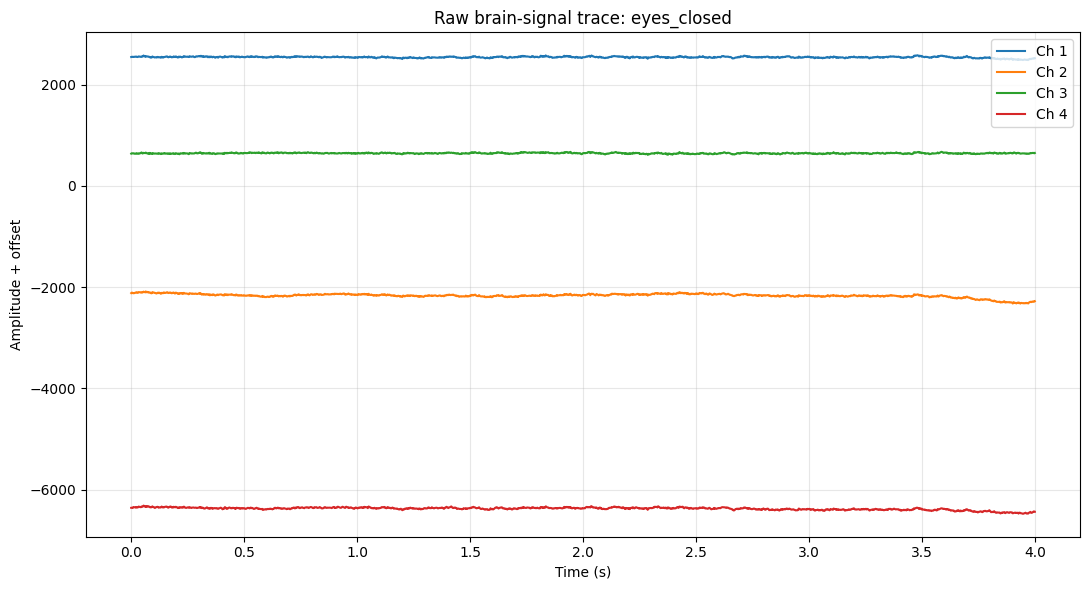

In [ ]:
# 10. Raw signal trace plot

def plot_raw_trace(segment_info, n_channels=4, seconds=4):
    data = segment_info['segment']
    sfreq = segment_info['sfreq']

    if data.shape[0] < data.shape[1]:
        data = data.T

    n_samples = min(int(seconds * sfreq), data.shape[0])
    subset = data[:n_samples, :n_channels]
    t = np.arange(n_samples) / sfreq

    plt.figure(figsize=(11, 6))
    offset = 0
    for i in range(subset.shape[1]):
        plt.plot(t, subset[:, i] + offset, label=f'Ch {i+1}')
        offset += 100

    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude + offset')
    plt.title(f"Raw brain-signal trace: {segment_info['condition']}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

if len(alpha_segments) > 0:
    plot_raw_trace(alpha_segments[0])
elif len(mental_segments) > 0:
    plot_raw_trace(mental_segments[0])
else:
    print('No raw segments available yet.')

## Visualization 2: feature boxplots

These are easy to read and good for slides.

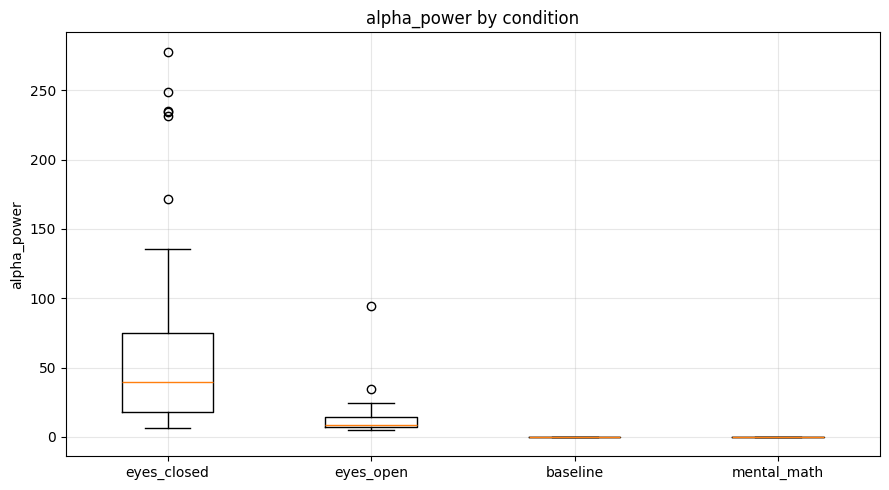

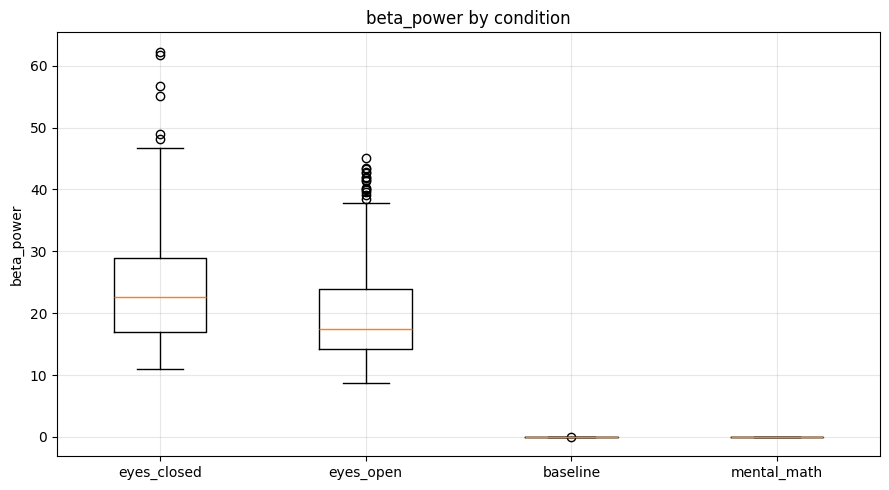

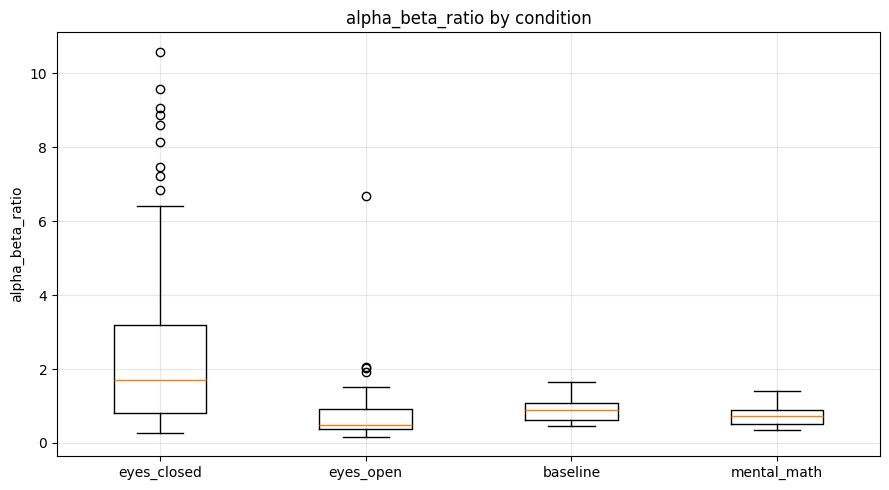

In [ ]:
# 11. Boxplots
if len(features) == 0:
    print('No features yet.')
else:
    condition_order = [c for c in ['eyes_closed', 'eyes_open', 'baseline', 'mental_math'] if c in features['condition'].unique()]

    def make_boxplot(metric):
        groups = [features.loc[features['condition'] == cond, metric].dropna().values for cond in condition_order]
        plt.figure(figsize=(9, 5))
        plt.boxplot(groups, tick_labels=condition_order)
        plt.title(f'{metric} by condition')
        plt.ylabel(metric)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    make_boxplot('alpha_power')
    make_boxplot('beta_power')
    make_boxplot('alpha_beta_ratio')

## Visualization 3: alpha vs beta scatter plot

This helps show whether conditions cluster differently.

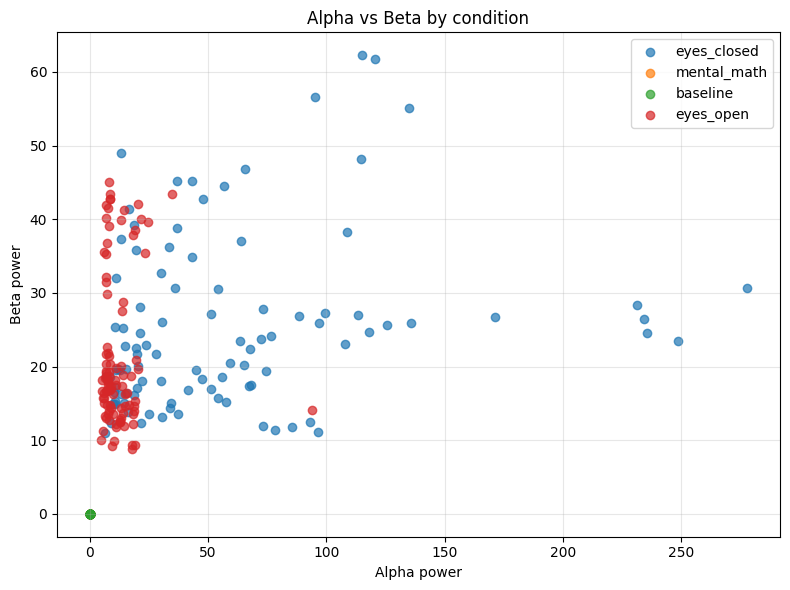

In [ ]:
# 12. Scatter plot
if len(features) == 0:
    print('No features yet.')
else:
    show_conditions = [c for c in ['eyes_closed', 'mental_math', 'baseline', 'eyes_open'] if c in features['condition'].unique()]
    plt.figure(figsize=(8, 6))
    for cond in show_conditions:
        sub = features[features['condition'] == cond]
        plt.scatter(sub['alpha_power'], sub['beta_power'], label=cond, alpha=0.7)

    plt.xlabel('Alpha power')
    plt.ylabel('Beta power')
    plt.title('Alpha vs Beta by condition')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Visualization 4: time-frequency heatmap

This is one of the most visually interesting signal plots.
It shows how signal power changes across time and frequency for one example segment.

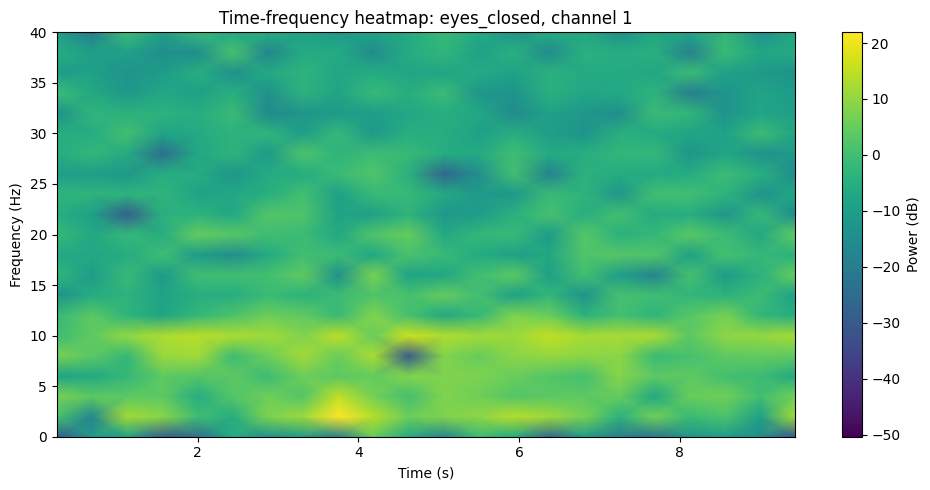

In [ ]:
# 13. Spectrogram heatmap
def plot_spectrogram(segment_info, channel_idx=0):
    data = segment_info['segment']
    sfreq = segment_info['sfreq']

    if data.shape[0] < data.shape[1]:
        data = data.T

    channel_data = data[:, channel_idx]
    f, t, Sxx = spectrogram(channel_data, fs=sfreq, nperseg=min(256, len(channel_data)))

    plt.figure(figsize=(10, 5))
    plt.pcolormesh(t, f, 10 * np.log10(Sxx + 1e-12), shading='gouraud')
    plt.ylim(0, 40)
    plt.xlabel('Time (s)')
    plt.ylabel('Frequency (Hz)')
    plt.title(f"Time-frequency heatmap: {segment_info['condition']}, channel {channel_idx+1}")
    plt.colorbar(label='Power (dB)')
    plt.tight_layout()
    plt.show()

if len(alpha_segments) > 0:
    plot_spectrogram(alpha_segments[0], channel_idx=0)
elif len(mental_segments) > 0:
    plot_spectrogram(mental_segments[0], channel_idx=0)
else:
    print('No segment available yet.')

## Visualization 5: scalp heatmap

This gives a brain-like top view of where alpha power differences are stronger or weaker across channels.

This one is especially helpful if you want the notebook to look more like a neuroscience project.

<Figure size 600x500 with 0 Axes>

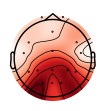

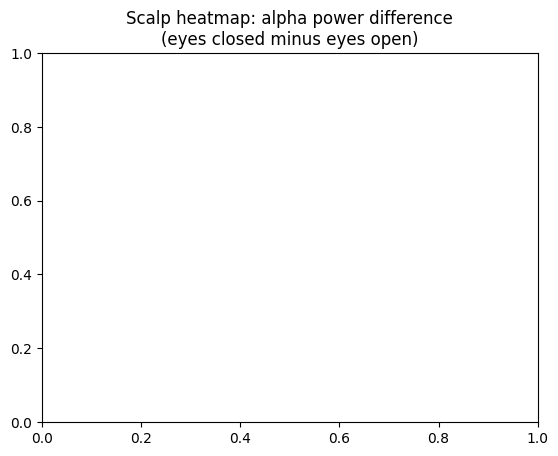

In [ ]:
# 14. Scalp topomap for Alpha Waves eyes closed vs eyes open

def per_channel_bandpower(data, sfreq, band):
    # data shape expected: samples x channels
    if data.shape[0] < data.shape[1]:
        data = data.T
    nperseg = min(int(2 * sfreq), data.shape[0])
    freqs, psd = welch(data, fs=sfreq, nperseg=nperseg, axis=0)
    band_mask = (freqs >= band[0]) & (freqs <= band[1])
    bp = np.trapz(psd[band_mask], freqs[band_mask], axis=0)
    return bp

if len(alpha_segments) == 0:
    print('Need Alpha Waves segments for the scalp heatmap.')
else:
    closed_segments = [seg['segment'] for seg in alpha_segments if seg['condition'] == 'eyes_closed']
    open_segments = [seg['segment'] for seg in alpha_segments if seg['condition'] == 'eyes_open']
    sfreq = alpha_segments[0]['sfreq']

    if len(closed_segments) > 0 and len(open_segments) > 0:
        closed_mean = np.mean([per_channel_bandpower(seg, sfreq, (8, 12)) for seg in closed_segments], axis=0)
        open_mean = np.mean([per_channel_bandpower(seg, sfreq, (8, 12)) for seg in open_segments], axis=0)
        diff = closed_mean - open_mean

        info = mne.create_info(ch_names=ALPHA_CHANNELS, sfreq=sfreq, ch_types='eeg')
        info.set_montage('standard_1020')

        plt.figure(figsize=(6, 5))
        mne.viz.plot_topomap(diff, info, show=True)
        plt.title('Scalp heatmap: alpha power difference\n(eyes closed minus eyes open)')
        plt.show()
    else:
        print('Need both eyes_closed and eyes_open segments for this plot.')

## Simple model

This is the first-pass machine learning section.
Keep it simple first.

                 precision    recall  f1-score   support

 low_engagement       1.00      0.96      0.98        25
high_engagement       0.90      1.00      0.95         9

       accuracy                           0.97        34
      macro avg       0.95      0.98      0.96        34
   weighted avg       0.97      0.97      0.97        34



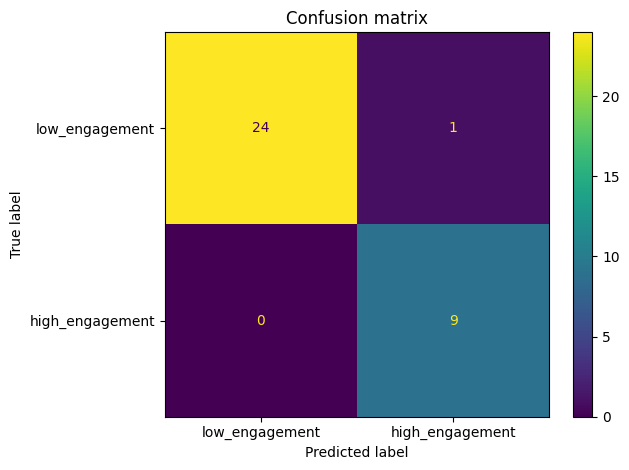

In [ ]:
# 15. Logistic Regression
feature_cols = [
    'theta_power',
    'alpha_power',
    'beta_power',
    'theta_rel_power',
    'alpha_rel_power',
    'beta_rel_power',
    'alpha_beta_ratio',
    'beta_alpha_ratio',
    'theta_beta_ratio',
]

if len(model_df) == 0:
    print('No model data yet.')
else:
    X = model_df[feature_cols]
    y = model_df['label']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )

    clf = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=2000))
    ])

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    print(classification_report(y_test, y_pred, target_names=['low_engagement', 'high_engagement']))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['low_engagement', 'high_engagement'])
    disp.plot()
    plt.title('Confusion matrix')
    plt.tight_layout()
    plt.show()

## What still needs work

### Missing or still weak
- better explanation of why these proxy labels make sense
- more polished figure captions
- better subject-level comparison
- optional OpenNeuro extension
- one cleaner final summary figure
- stronger interpretation of limitations

### Good add-on
- add a PSD line plot by condition
- add a table of means and standard deviations
- test whether subject averaging changes the result
- improve the scalp heatmap styling
- try one better comparison between baseline and mental task

In [ ]:
# 16. Save processed table
if len(features) == 0:
    print('No features to save yet.')
else:
    out_csv = PROCESSED / 'attention_boredom_collab_features.csv'
    features.to_csv(out_csv, index=False)
    print('Saved to:', out_csv)

No features to save yet.


## Reflection and takeaway

This collaborative notebook turns a personal question about doomscrolling into a shared engineering workflow.

What it taught us:
- how to turn a vague human experience into a careful data question
- how to work with public scientific datasets
- how to use signal processing and simple ML together
- how to build a notebook that is both technical and readable
- how to collaborate by improving one section at a time instead of depending on one person

The main value of this project is not just the final number from the model.
It is also the process of asking better questions, working with real data, and learning how to communicate honest results.